#Question 2 (SVM Classifier)
Data:`mobile_price.csv`  


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

#2a) 

In [ ]:
df = pd.read_csv('mobile_price.csv')
print(df.shape)
df.head()

In [ ]:
X = df.drop(columns=['price_range'])
y = df['price_range']

#split: 60% train, 40% temp  withrandom_state=42
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

#split: temp in 50% validation and 50% test with random_state=42
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f'Train size : {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Val size   : {len(X_val)}   ({len(X_val)/len(df)*100:.0f}%)')
print(f'Test size  : {len(X_test)}  ({len(X_test)/len(df)*100:.0f}%)')

In [ ]:
def report_metrics(model, X, y, split_name):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1  = f1_score(y, preds, average='weighted')
    print(f'{split_name:12s} | Accuracy: {acc:.4f} | F1-score (weighted): {f1:.4f}')

svm = SVC(C=1.0, random_state=42)
svm.fit(X_train, y_train)

report_metrics(svm, X_train, y_train, 'Train')
report_metrics(svm, X_val,   y_val,   'Validation')
report_metrics(svm, X_test,  y_test,  'Test')

# 2b) 

In [10]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

results = {
    'train_acc': [], 'val_acc': [], 'test_acc': [],
    'train_f1':  [], 'val_f1':  [], 'test_f1':  []
}

for C in C_values:
    model = SVC(C=C, random_state=42)
    model.fit(X_train, y_train)

    for X_split, y_split, acc_key, f1_key in [
        (X_train, y_train, 'train_acc', 'train_f1'),
        (X_val,   y_val,   'val_acc',   'val_f1'),
        (X_test,  y_test,  'test_acc',  'test_f1'),
    ]:
        preds = model.predict(X_split)
        results[acc_key].append(accuracy_score(y_split, preds))
        results[f1_key].append(f1_score(y_split, preds, average='weighted'))

    print(f'C={C:<8} | '
          f'Train acc={results["train_acc"][-1]:.4f}  '
          f'Val acc={results["val_acc"][-1]:.4f}  '
          f'Test acc={results["test_acc"][-1]:.4f}')

C=0.001    | Train acc=0.2550  Val acc=0.2450  Test acc=0.2400
C=0.01     | Train acc=0.4908  Val acc=0.4875  Test acc=0.4425
C=0.1      | Train acc=0.9050  Val acc=0.9025  Test acc=0.9000
C=1        | Train acc=0.9450  Val acc=0.9450  Test acc=0.9575
C=10       | Train acc=0.9658  Val acc=0.9575  Test acc=0.9650
C=100      | Train acc=0.9792  Val acc=0.9725  Test acc=0.9775
C=1000     | Train acc=0.9900  Val acc=0.9700  Test acc=0.9775
C=10000    | Train acc=0.9975  Val acc=0.9700  Test acc=0.9650


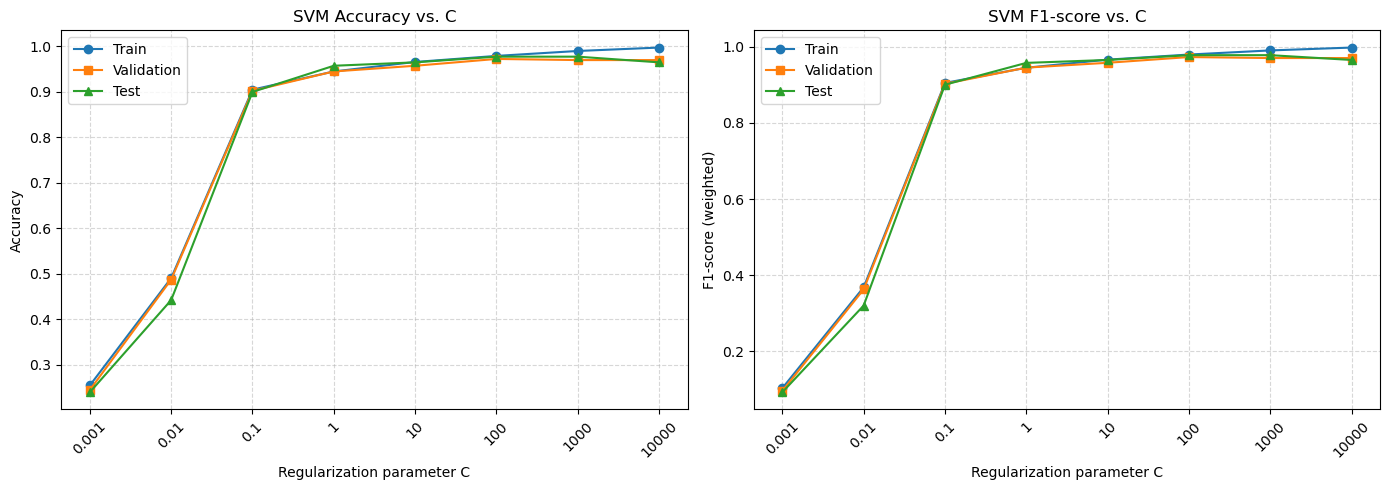

In [ ]:
#Visualization
x_ticks  = range(len(C_values))
x_labels = [str(c) for c in C_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Accuracy
ax1.plot(x_ticks, results['train_acc'], marker='o', label='Train')
ax1.plot(x_ticks, results['val_acc'],   marker='s', label='Validation')
ax1.plot(x_ticks, results['test_acc'],  marker='^', label='Test')
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_labels, rotation=45)
ax1.set_xlabel('Regularization parameter C')
ax1.set_ylabel('Accuracy')
ax1.set_title('SVM Accuracy vs. C')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

#F1-score--
ax2.plot(x_ticks, results['train_f1'], marker='o', label='Train')
ax2.plot(x_ticks, results['val_f1'],   marker='s', label='Validation')
ax2.plot(x_ticks, results['test_f1'],  marker='^', label='Test')
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(x_labels, rotation=45)
ax2.set_xlabel('Regularization parameter C')
ax2.set_ylabel('F1-score (weighted)')
ax2.set_title('SVM F1-score vs. C')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('q2b_svm_performance.png', dpi=150)
plt.show()

In [12]:
results_df = pd.DataFrame({
    'C':             C_values,
    'Train Acc':     results['train_acc'],
    'Val Acc':       results['val_acc'],
    'Test Acc':      results['test_acc'],
    'Train F1':      results['train_f1'],
    'Val F1':        results['val_f1'],
    'Test F1':       results['test_f1'],
}).set_index('C')

results_df.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen')

,Train Acc,Val Acc,Test Acc,Train F1,Val F1,Test F1
C,,,,,,
0.001000,0.2550,0.2450,0.2400,0.1036,0.0964,0.0929
0.010000,0.4908,0.4875,0.4425,0.3683,0.3628,0.3204
0.100000,0.9050,0.9025,0.9000,0.9047,0.9024,0.9000
1.000000,0.9450,0.9450,0.9575,0.9445,0.9448,0.9573
10.000000,0.9658,0.9575,0.9650,0.9658,0.9575,0.9650
100.000000,0.9792,0.9725,0.9775,0.9792,0.9726,0.9776
1000.000000,0.9900,0.9700,0.9775,0.9900,0.9700,0.9775
10000.000000,0.9975,0.9700,0.9650,0.9975,0.9700,0.9650
